# S03: Maximum common substructure in reaction informatics

## Aim of this talktorial

This talktorial (**S03**) introduces **maximum common substructure (MCS)** as a
pragmatic alignment tool for **reaction modeling** when exact graph
isomorphisms are unavailable due to edits, substitutions, or missing components.

We focus on two core ideas:

1. **MCS-based alignment**  
   Using MCS to align molecules that differ structurally, providing a robust
   alternative to exact pattern matching.

2. **Reaction rebalancing**  
   Combining **rule-based reasoning** with MCS to detect missing species and
   rebalance reactions consistently.


We keep implementations minimal and transparent, using:

- **RDKit** for chemistry-aware substructure/MCS behavior (sanitization, aromaticity, valence, MCS) [[1]](#ref-1).
- **NetworkX** for explicit, attribute-based subgraph morphisms and symmetry-aware deduplication [[2]](#ref-2).

---

## Learning outcomes

After completing this talktorial, you will be able to:

- Compute and interpret **MCS** as a shared labeled subgraph.
- Use MCS to align reactants and products in **partial or noisy reactions**.
- Apply MCS-based alignment to **reaction rebalancing** tasks.

---

## Outline

- [0. Setup & Data](#0-setup--data)
- [1. Maximum Common Substructure](#1-graph-isomorphism)
- [2. Reaction alignment](#2-reaction-alignment)
- [3. Reaction rebalancing](#3-reaction-rebalancing)
- [4. Discussion](#4-discussion)
- [5. Quiz](#5-quiz)
- [6. References](#6-references)

## 0. Setup & Data

In [1]:
import rdkit
from rdkit import Chem
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from synedu.Utils.vis import draw_molecular_graph  # for visualization

print("RDKit version:", rdkit.__version__)
print("NetworkX version:", nx.__version__)

DATA_DIR = Path("data")
CSV_PATH = DATA_DIR / "molecules.csv"
df = pd.read_csv(CSV_PATH)
df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)
display(df)

RDKit version: 2025.09.3
NetworkX version: 3.6.1


,smiles,name,mol
0,CCO,ethanol,<rdkit.Chem.rdchem.Mol object at 0x7fcadc21e7a0>
1,CCCl,chloroethane,<rdkit.Chem.rdchem.Mol object at 0x7fcadc21e880>
2,CCOCC,diethyl ether,<rdkit.Chem.rdchem.Mol object at 0x7fcadc21e8f0>
3,O,water,<rdkit.Chem.rdchem.Mol object at 0x7fcadc21e960>
4,NCC(=O)O,glycine,<rdkit.Chem.rdchem.Mol object at 0x7fcadc21e9d0>
...,...,...,...
995,CNCC(O)c1ccc(O)cc1,oxedrine,<rdkit.Chem.rdchem.Mol object at 0x7fcadc281f50>
996,Cc1nc(Nc2ccc(F)cc2)nc(N2CCc3ccccc3C2C)c1C,revaprazan,<rdkit.Chem.rdchem.Mol object at 0x7fcadc281fc0>
997,O=C(O)CCC(=O)c1ccc2c(c1)-c1cccc3cccc-2c13,florantyrone,<rdkit.Chem.rdchem.Mol object at 0x7fcadc282030>
998,COC(=O)CCC[N+](C)(C)C,carpronium,<rdkit.Chem.rdchem.Mol object at 0x7fcadc2820a0>


## 1. Maximum Common Substructure

The **Maximum Common Substructure (MCS)** [[3]](#ref-3)[[4]](#ref-4) problem seeks the largest subgraph
shared by two molecular graphs. It serves as a core **alignment primitive** for
molecular similarity, substructure transfer, and as a common starting point for
**atom mapping**.

---

### 1.1 Theory

Let
$$
G = \bigl( V_G, E_G, a_G, b_G \bigr), \qquad
H = \bigl( V_H, E_H, a_H, b_H \bigr)
$$
be **labeled molecular graphs**, where
$$
a(\cdot) \text{ denotes atom labels}, \qquad
b(\cdot) \text{ denotes bond labels}.
$$

A graph
$$
S = (V_S, E_S, a_S, b_S)
$$
is a **common subgraph** of \(G\) and \(H\) if there exist **injective graph
morphisms**
$$
f : S \hookrightarrow G, \qquad
g : S \hookrightarrow H,
$$
that preserve adjacency and all labels.

An **MCS** is a common subgraph
$$
S^\star
$$
that maximizes the number of vertices, i.e.
$$
|V(S^\star)| \;\ge\; |V(S)| \qquad
\forall\, S \text{ such that } S \subseteq G \text{ and } S \subseteq H .
$$

**Practical notes.**
- MCSs are generally **not unique**.
- Imposing chemical constraints (atom and bond types, aromaticity, ring
  membership, chirality) restricts the admissible morphisms and can change the
  resulting MCS.


### 1.2. RDkit MCS

In **RDKit**, the **maximum common substructure (MCS)** can be computed using
`rdkit.Chem.rdFMCS` [[5]](#ref-5). 

RDKit MCS is commonly used for molecular alignment, reaction analysis, and as a
basis for atom mapping.

MCS SMARTS: [#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1
Mol 1: 7 atoms, MCS matches: 1
Mol 2: 7 atoms, MCS matches: 1

Atom mapping (mol1_atom -> mol2_atom) for first embeddings:
[(1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6)]


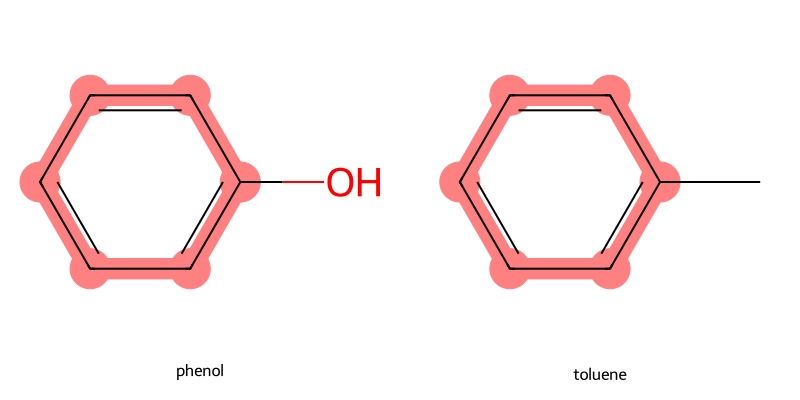

In [2]:
from rdkit import Chem
from rdkit.Chem import rdFMCS, Draw


def rdkit_mcs(
    mols,
    timeout: int = 10,
    ringMatchesRingOnly: bool = True,
    atomCompare=rdFMCS.AtomCompare.CompareElements,
    bondCompare=rdFMCS.BondCompare.CompareOrder,
):
    """
    Return the MCS SMARTS string and the rdFMCS result object.
    `mols` can be a list of RDKit Mol objects or SMILES strings.
    """
    mol_objs = [Chem.MolFromSmiles(s) if isinstance(s, str) else s for s in mols]
    res = rdFMCS.FindMCS(
        mol_objs,
        atomCompare=atomCompare,
        bondCompare=bondCompare,
        ringMatchesRingOnly=ringMatchesRingOnly,
        timeout=timeout,
    )
    return res.smartsString, res


def show_mcs_and_highlight(
    mols, smarts=None, show_all_matches=False, subimg_size=(300, 300)
):
    """
    Compute (or accept) MCS SMARTS, enumerate matches in each molecule,
    print a first-match atom-index mapping, and draw the molecules with
    highlighted MCS atoms.
    """
    # Accept SMILES or Mol
    mol_objs = [Chem.MolFromSmiles(s) if isinstance(s, str) else s for s in mols]
    if smarts is None:
        smarts, _ = rdkit_mcs(mol_objs)
    mcs_query = Chem.MolFromSmarts(smarts)

    # find matches
    matches = [tuple(m.GetSubstructMatches(mcs_query)) for m in mol_objs]
    match_counts = [len(ms) for ms in matches]

    print("MCS SMARTS:", smarts)
    for i, (m, cnt) in enumerate(zip(mol_objs, match_counts)):
        print(f"Mol {i+1}: {m.GetNumAtoms()} atoms, MCS matches: {cnt}")

    # If no matches found (shouldn't happen), return
    if any(cnt == 0 for cnt in match_counts):
        print("Warning: no MCS embedding found in one or more molecules.")
        return

    # Show mapping for the *first* embedding in each molecule
    first_matches = [ms[0] for ms in matches]
    mapping = (
        list(zip(first_matches[0], first_matches[1]))
        if len(first_matches) >= 2
        else None
    )
    if mapping:
        print("\nAtom mapping (mol1_atom -> mol2_atom) for first embeddings:")
        print(mapping)

    # Prepare highlight lists: choose which embedding to highlight for each molecule
    if show_all_matches:
        # create list-of-lists where we highlight all embeddings (flatten duplicates visually)
        hl_lists = [list(set(sum([list(t) for t in ms], []))) for ms in matches]
    else:
        hl_lists = [list(ms[0]) for ms in matches]

    # Legend labels
    legends = [
        mol.GetProp("_Name") if mol.HasProp("_Name") else f"Mol {i+1}"
        for i, mol in enumerate(mol_objs)
    ]

    # Draw side-by-side with highlighted atoms
    img = Draw.MolsToGridImage(
        mol_objs,
        molsPerRow=len(mol_objs),
        subImgSize=subimg_size,
        legends=legends,
        highlightAtomLists=hl_lists,
    )
    display(img)  # in a Jupyter notebook; returns PIL Image otherwise


m1 = Chem.MolFromSmiles("Oc1ccccc1")
m1.SetProp("_Name", "phenol")
m2 = Chem.MolFromSmiles("Cc1ccccc1")
m2.SetProp("_Name", "toluene")

smarts, res = rdkit_mcs([m1, m2])
show_mcs_and_highlight(
    [m1, m2], smarts=smarts, show_all_matches=False, subimg_size=(400, 400)
)

**Q1 — Compute the MCS between ethanol and another molecule**

Use **RDKit MCS** to compute the maximum common substructure between **ethanol**
and each molecule in the table, and record the **size of the MCS**.

This exercise shows how RDKit abstracts chemical similarity beyond strict
subgraph containment.

---

**Step-by-step tasks**

1. **Select ethanol as the reference molecule**  
   Use the RDKit molecule corresponding to ethanol (row 0).

2. **Compute RDKit MCS**  
   For each molecule, compute the MCS SMARTS between ethanol and the molecule
   using `rdkit_mcs`.

3. **Convert SMARTS to a molecule**  
   Turn the SMARTS into an RDKit query molecule.

4. **Measure MCS size**  
   Record the number of atoms in the MCS (or `0` if no MCS is found).

5. **Store the result**  
   Add a column `mcs_size_ethanol_rdkit`.

<details> <summary><b>Solution:</b></summary>

```python
ethanol_mol = df.loc[0, "mol"]

def rdkit_mcs_size_with_ethanol(mol):
    smarts, _ = rdkit_mcs([ethanol_mol, mol])
    if not smarts:
        return 0
    mcs_mol = Chem.MolFromSmarts(smarts)
    if mcs_mol is None:
        return 0
    return mcs_mol.GetNumAtoms()

df["mcs_size_ethanol_rdkit"] = df["mol"].apply(rdkit_mcs_size_with_ethanol)
df
```

</details>

### 1.3. NetworkX MCS

In [3]:
from __future__ import annotations

from itertools import combinations
from typing import Dict, Set, Tuple

import networkx as nx
from networkx.algorithms import isomorphism as iso
from rdkit import Chem


def nx_mcs(
    G: nx.Graph,
    H: nx.Graph,
    *,
    node_match,
    edge_match,
) -> tuple[nx.Graph, Dict[int, int]]:
    """
    Return one maximum common induced subgraph SG of G, plus a node mapping SG->H.
    Exponential; for teaching only.
    """
    nodes = list(G.nodes())
    for k in range(len(nodes), 0, -1):
        for subset in combinations(nodes, k):
            SG = G.subgraph(subset).copy()

            GM = iso.GraphMatcher(H, SG, node_match=node_match, edge_match=edge_match)
            if GM.subgraph_is_isomorphic():
                # GraphMatcher mapping is H -> SG; invert to get SG -> H
                h_to_sg = next(GM.subgraph_isomorphisms_iter())
                sg_to_h = {sg: h for h, sg in h_to_sg.items()}
                return SG, sg_to_h

    return nx.Graph(), {}


def _map_edges(
    SG: nx.Graph, sg_to_h: Dict[int, int], H: nx.Graph
) -> Set[Tuple[int, int]]:
    """Map SG edges into H using sg_to_h; returns undirected edge tuples."""
    out: Set[Tuple[int, int]] = set()
    for u, v in SG.edges():
        hu, hv = sg_to_h[u], sg_to_h[v]
        if H.has_edge(hu, hv):
            out.add((hu, hv))
    return out

MCS nodes: 6 MCS edges: 6
One SG->H mapping (first): {1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6}


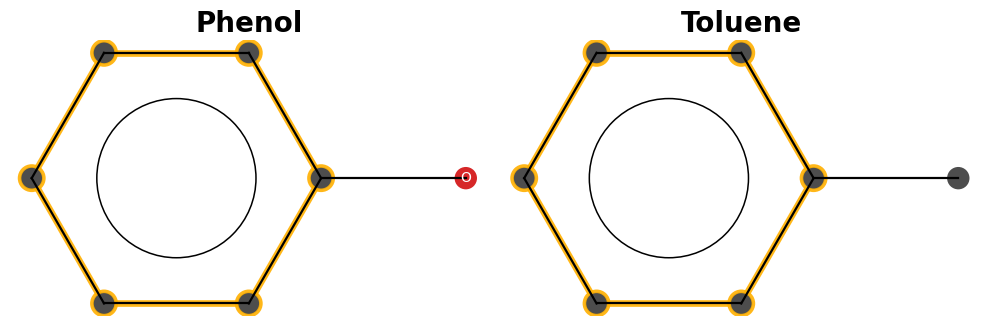

In [4]:
from synedu.Utils import mol_to_graph, node_match, edge_match, draw_molecular_graph
import matplotlib.pyplot as plt


m1 = Chem.MolFromSmiles("Oc1ccccc1")  # phenol
m2 = Chem.MolFromSmiles("Cc1ccccc1")  # toluene

# Convert to labeled NetworkX graphs (nodes must be atom indices)
m1_g = mol_to_graph(m1)
m2_g = mol_to_graph(m2)

# Compute NX MCS + one embedding (SG -> m2_g mapping)
SG, sg_to_h = nx_mcs(m1_g, m2_g, node_match=node_match, edge_match=edge_match)

print("MCS nodes:", SG.number_of_nodes(), "MCS edges:", SG.number_of_edges())
print("One SG->H mapping (first):", sg_to_h)

# Highlight sets
hl_m1_nodes = set(SG.nodes())
hl_m1_edges = set(SG.edges())

hl_m2_nodes = {sg_to_h[n] for n in SG.nodes()}
hl_m2_edges = _map_edges(SG, sg_to_h, m2_g)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

draw_molecular_graph(
    m1_g,
    mol=m1,
    ax=axes[0],
    include_mol=False,
    highlight_nodes=hl_m1_nodes,
    highlight_edges=hl_m1_edges,
)
axes[0].set_title("Phenol", fontsize=20, weight='bold')

draw_molecular_graph(
    m2_g,
    mol=m2,
    ax=axes[1],
    include_mol=False,
    highlight_nodes=hl_m2_nodes,
    highlight_edges=hl_m2_edges,
)
axes[1].set_title("Toluene", fontsize=20, weight='bold')

plt.tight_layout()
plt.show()

**Q2 — Compute the MCS between ethanol and another molecule**

Compute the **MCS** between **ethanol** and each
molecule in the table using the **NetworkX-based MCS implementation**, and
record the size of the resulting common subgraph.

This exercise emphasizes a **strict graph-theoretic view** of MCS, in contrast
to the chemistry-aware RDKit approach in Q4.

---

**Step-by-step tasks**

1. **Select ethanol as the reference graph**  
   Use the NetworkX graph corresponding to ethanol (row 0).

2. **Compute NetworkX MCS**  
   For each molecule graph, compute an MCS using `nx_mcs`.

3. **Measure MCS size**  
   Record the number of nodes (atoms) in the resulting MCS graph.

4. **Store the result**  
   Add a new column `mcs_size_ethanol_nx` to the dataframe.

<details> <summary><b>Solution:</b></summary>

```python
# Reference graph: ethanol
df['graph'] = df['mol'].apply(mol_to_graph)
ethanol_G = df.loc[0, "graph"]

def nx_mcs_size_with_ethanol(host_G):
    S, _ = nx_mcs(
        ethanol_G,
        host_G,
        node_match=node_match,
        edge_match=edge_match,
    )
    if S is None:
        return 0
    return S.number_of_nodes()

# Add NetworkX MCS size column
df["mcs_size_ethanol_nx"] = df["graph"].apply(nx_mcs_size_with_ethanol)
```

</details>

Now we inspect the difference between rdkit and networkx

```python
df[df['mcs_size_ethanol_rdkit'] != df['mcs_size_ethanol_nx']]
```

Most discrepancies originate from **ring systems**. RDKit MCS is *chemistry-first*, enforcing ring–chain consistency, whereas NetworkX MCS is *graph-first* and performs purely topological matching. With `RingMatchesRingOnly=True`, RDKit allows atom matches only when both the pattern and host atoms belong to rings, preventing acyclic–ring correspondences. Consequently, cyclic hydrocarbons yield zero MCS with ethanol under RDKit but non-zero matches under unconstrained graph matching.


## 2. Rule-based reaction rebalancing

We utilize idea from *[Reaction rebalancing: a novel approach to curating reaction databases](https://link.springer.com/article/10.1186/s13321-024-00875-4)* [[6]](#ref-6). 

---

### 2.1 Reaction decomposition

Given a reaction SMILES
$$
r \;=\; R_1 + R_2 + \cdots \;\longrightarrow\; P_1 + P_2 + \cdots ,
$$
define the reactant and product multisets
$$
\mathcal{R}=\{R_i\}, \qquad \mathcal{P}=\{P_j\}.
$$

---

### 2.2 Formula representation

Let $\mathcal{E}$ be the set of chemical elements.
Each molecule $M$ is represented by its element-count vector
$$
\phi(M) \in \mathbb{N}^{|\mathcal{E}|}.
$$
Total formulas are
$$
\Phi_{\mathcal{R}}=\sum_{R_i\in\mathcal{R}}\phi(R_i), \qquad
\Phi_{\mathcal{P}}=\sum_{P_j\in\mathcal{P}}\phi(P_j).
$$

---

### 2.3 Imbalance detection

Define the imbalance vector
$$
\Delta \;=\; \Phi_{\mathcal{R}}-\Phi_{\mathcal{P}} \;\in\; \mathbb{Z}^{|\mathcal{E}|}.
$$
The reaction is balanced iff $\Delta=\mathbf{0}$.

---

### 2.4 Auxiliary-species imputation

Let $\mathcal{L}=\{A_k\}$ be a library of auxiliary species
(e.g. $\mathrm{H_2O}$) with formulas $\phi(A_k)$.
We seek coefficients $c_k\in\mathbb{N}$ such that
$$
\Delta = \sum_k c_k\,\phi(A_k).
$$

---

### 2.5 Reaction update

If a solution exists, rebalance the reaction by adding
$c_k A_k$ to the deficient side:
$$
r' =
\begin{cases}
\mathcal{R}\cup\{c_kA_k\} \rightarrow \mathcal{P}, & \Delta>0,\\
\mathcal{R}\rightarrow \mathcal{P}\cup\{c_kA_k\}, & \Delta<0.
\end{cases}
$$

In SMILES, this corresponds to appending the auxiliary species
(e.g. `O` for $\mathrm{H_2O}$).


Now consider the following simple reaction. 
By comparing the total molecular formulas of the reactant and product sides,
we can immediately detect a **missing water molecule on the product side**.

[16:19:37] reactant 0 has no mapped atoms.
[16:19:37] product 0 has no mapped atoms.


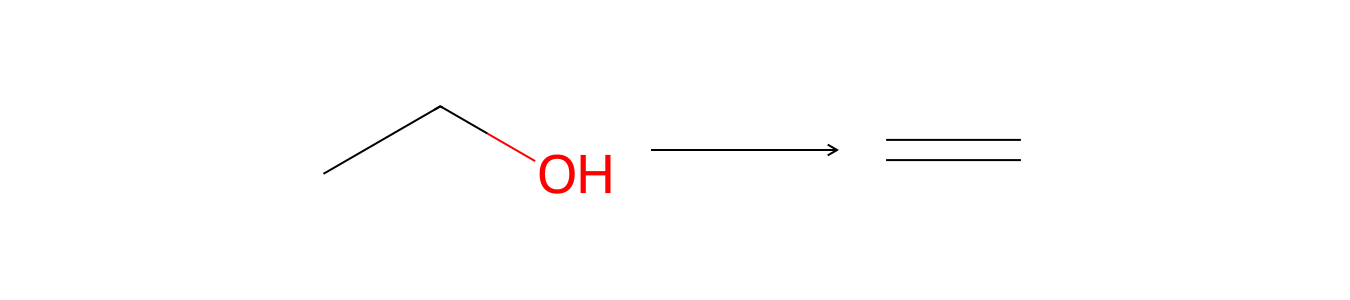

In [5]:
from synedu.Utils.rxn_vis import visualize_reaction
from IPython.display import SVG


rsmi = 'CCO>>C=C'

svg = visualize_reaction(
    rsmi,
    svg=True,
    highlight_changes=True,
    legend="E1 example",
)

display(SVG(svg))

To automate this imputation, we introduce a small set of utility functions
for parsing reactions, computing formula imbalances, and resolving them
using predefined auxiliary species.


In [6]:
from __future__ import annotations

from collections import Counter
from typing import Tuple

from rdkit import Chem


# Reaction decomposition


def parse_reaction_smiles(rsmi: str) -> Tuple[list[Chem.Mol], list[Chem.Mol]]:
    """
    Parse a reaction SMILES into reactant and product molecule lists.

    Parameters
    ----------
    rsmi : str
        Reaction SMILES, e.g. "CCO.O>>CC=O"

    Returns
    -------
    reactants : list[Chem.Mol]
    products  : list[Chem.Mol]
    """
    try:
        lhs, rhs = rsmi.split(">>")
    except ValueError:
        raise ValueError("Reaction SMILES must contain '>>'")

    reactants = [Chem.MolFromSmiles(s) for s in lhs.split(".") if s]
    products = [Chem.MolFromSmiles(s) for s in rhs.split(".") if s]

    if any(m is None for m in reactants + products):
        raise ValueError("Invalid molecule in reaction SMILES")

    return reactants, products


# Formula representation


def molecular_formula(mol: Chem.Mol) -> Counter[str]:
    """
    Compute the molecular formula φ(M) as an element-count vector.

    Returns
    -------
    Counter[str]
        Mapping element symbol -> atom count
    """
    mol = Chem.AddHs(mol)

    formula = Counter()
    for atom in mol.GetAtoms():
        formula[atom.GetSymbol()] += 1
    return formula


def total_formula(mols: list[Chem.Mol]) -> Counter[str]:
    """
    Compute total formula Φ = sum φ(M) over a list of molecules.
    """
    total = Counter()
    for m in mols:
        total += molecular_formula(m)
    return total


# Imbalance detection

from collections import Counter
from typing import Literal, Tuple


def signed_difference(a: Counter[str], b: Counter[str]) -> Counter[str]:
    """
    Compute signed element-wise difference a - b
    without dropping negative values.
    """
    delta = Counter()
    for elem in set(a) | set(b):
        v = a.get(elem, 0) - b.get(elem, 0)
        if v != 0:
            delta[elem] = v
    return delta


def reaction_imbalance(
    rsmi: str,
) -> Tuple[
    Counter[str],
    Literal[
        "balanced",
        "missing_in_products",
        "missing_in_reactants",
        "missing_in_both_sides",
    ],
]:
    """
    Compute the reaction imbalance vector Δ = Φ_R − Φ_P
    and classify where material is missing.

    Returns
    -------
    delta : Counter[str]
        Element-wise imbalance (positive = excess on reactant side)
    status : str
        One of:
        - 'balanced'
        - 'missing_in_products'
        - 'missing_in_reactants'
        - 'missing_in_both_sides'
    """
    reactants, products = parse_reaction_smiles(rsmi)

    phi_R = total_formula(reactants)
    phi_P = total_formula(products)
    delta = signed_difference(phi_R, phi_P)

    if not delta:
        return delta, "balanced"

    has_pos = any(v > 0 for v in delta.values())
    has_neg = any(v < 0 for v in delta.values())

    if has_pos and not has_neg:
        status = "missing_in_products"
    elif has_neg and not has_pos:
        status = "missing_in_reactants"
    else:
        status = "missing_in_both_sides"

    return delta, status

In [7]:
rsmi = 'CCO>>C=C'
delta, status = reaction_imbalance(rsmi)
print(delta, status)

Counter({'H': 2, 'O': 1}) missing_in_products


In [8]:
from collections import Counter
from typing import Dict, Optional

AUX_LIBRARY: Dict[str, Counter[str]] = {
    "O": Counter({"H": 2, "O": 1}),  # H2O
    "[H+]": Counter({"H": 1}),
    "[OH-]": Counter({"H": 1, "O": 1}),
}

**Q3 — Auxiliary imputation feasibility**

You are given an element-wise imbalance vector  
$$
\Delta \in \mathbb{Z}^{|\mathcal E|}
$$
and an auxiliary species $A$ with molecular formula  
$$
\phi(A) \in \mathbb{N}^{|\mathcal E|}.
$$

The goal is to decide whether the imbalance can be resolved by adding
$c$ copies of $A$, i.e.
$$
\Delta = c \cdot \phi(A), \qquad c \in \mathbb{N}.
$$

---

<details>
<summary><b>Hint:</b></summary>

Think element-wise.  
If such a $c$ exists, then for every element $e$,
the ratio $\Delta_e / \phi_e(A)$ must be:
1. an integer,
2. the same for all elements,
3. and strictly positive.

Also ensure that no extra elements remain unexplained.

</details>

---

<details>
<summary><b>Solution:</b></summary>

```python
from collections import Counter
from typing import Optional


def can_impute_with_aux(
    delta: Counter[str],
    aux_formula: Counter[str],
) -> Optional[int]:
    """
    Check whether Δ can be written as c · φ(A).
    """
    if not delta:
        return 0

    ratios = []

    for elem, count in aux_formula.items():
        if elem not in delta:
            return None
        if delta[elem] % count != 0:
            return None
        ratios.append(delta[elem] // count)

    if not ratios or len(set(ratios)) != 1:
        return None

    c = ratios[0]
    if c <= 0:
        return None

    remainder = delta - Counter({k: c * v for k, v in aux_formula.items()})
    if remainder:
        return None

    return c
```

</details>

In [9]:
def impute_rsmi_rule(
    rsmi: str,
    delta: Counter[str],
    status: str,
    library: Dict[str, Counter[str]] = AUX_LIBRARY,
) -> Optional[str]:
    if status == "balanced":
        return rsmi

    if status == "missing_in_both_sides":
        return None

    lhs, rhs = rsmi.split(">>")
    # decide direction
    if status == "missing_in_products":
        target_delta = delta
        side = "products"
    elif status == "missing_in_reactants":
        target_delta = -delta
        side = "reactants"
    else:
        return None

    # try library
    for aux_smiles, formula in library.items():
        c = can_impute_with_aux(target_delta, formula)
        if c is None:
            continue

        aux_block = ".".join([aux_smiles] * c)

        if side == "products":
            rhs = rhs + "." + aux_block if rhs else aux_block
        else:
            lhs = lhs + "." + aux_block if lhs else aux_block

        return f"{lhs}>>{rhs}"

    return None


def can_impute_with_aux(
    delta: Counter[str],
    aux_formula: Counter[str],
) -> Optional[int]:
    """
    Check whether Δ can be written as c · φ(A).
    """
    if not delta:
        return 0

    ratios = []

    for elem, count in aux_formula.items():
        if elem not in delta:
            return None
        if delta[elem] % count != 0:
            return None
        ratios.append(delta[elem] // count)

    if not ratios or len(set(ratios)) != 1:
        return None

    c = ratios[0]
    if c <= 0:
        return None

    remainder = delta - Counter({k: c * v for k, v in aux_formula.items()})
    if remainder:
        return None

    return c

Now try with the above example

CCO>>C=C.O


[16:19:37] reactant 0 has no mapped atoms.
[16:19:37] product 0 has no mapped atoms.
[16:19:37] product 1 has no mapped atoms.


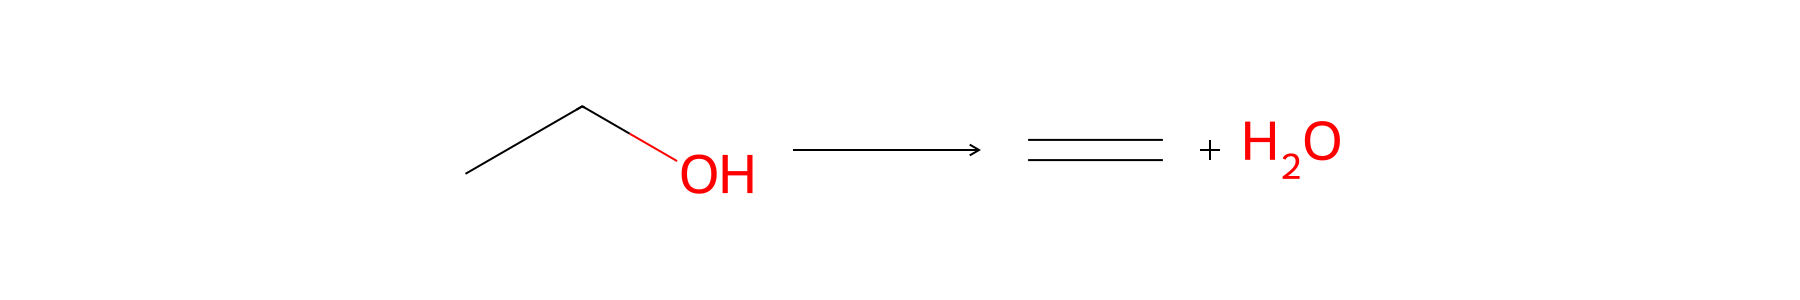

In [10]:
delta, status = reaction_imbalance(rsmi)
rsmi_balanced = impute_rsmi_rule(rsmi, delta, status, library=AUX_LIBRARY)

print(rsmi_balanced)
if rsmi_balanced:
    svg = visualize_reaction(
        rsmi_balanced,
        svg=True,
        highlight_changes=True,
        legend="E1 example",
    )

    display(SVG(svg))

**Q4 — Rebalance some reactions**
 
Now, extend library to rebalance these reactions

```text
CC(C)O>>CC(C)Cl.O
CC(C)Cl>>CC(C)N.Cl
CC(=O)O>>CC(=O)OC.O
```
---

<details>
<summary><b>Solution:</b></summary>

```python
AUX_LIBRARY: Dict[str, Counter[str]] = {
    "O": Counter({"H": 2, "O": 1}),   # H2O
    "[H+]": Counter({"H": 1}),
    "[OH-]": Counter({"H": 1, "O": 1}),
    "N": Counter({"N": 1, "H": 3}),   # NH3
    "Cl": Counter({"H": 1, "Cl": 1}),   # HCl
    "CO": Counter({"C": 1, "H": 4, "O": 1}),   # CH3OH
}
rsmis = ["CC(C)O>>CC(C)Cl.O", "CC(C)Cl>>CC(C)N.Cl", "CC(=O)O>>CC(=O)OC.O"]

new_rsmis = []
for rsmi in rsmis:
    delta, status = reaction_imbalance(rsmi)
    rsmi_balanced = impute_rsmi(rsmi, delta, status, library=AUX_LIBRARY)
    if rsmi_balanced:
        new_rsmis.append(rsmi_balanced)
```

## 3. MCS-based reaction rebalancing

For **non-carbon compounds**, missing species can often be imputed from a
finite library. In contrast, for **carbon-containing compounds**, the space of
possible structures grows exponentially, making library-based enumeration
impractical at scale.

Instead, we use **reaction alignment** to identify missing **structural motifs**
via MCS and apply **rule-based reasoning** to complete and rebalance reactions.

In this section, we directly use functionality from **SynKit** [[6]](#ref-6)
(`pip install synkit`) and explore an established tool for reaction rebalancing,
**SynRBL** [[7]](#ref-7) (`pip install synrbl`).

The focus is on applying **MCS-based alignment** to detect missing species,
infer stoichiometry, and rebalance reactions in a chemically consistent manner.


(Counter({'C': 8, 'H': 6, 'O': 2}), 'missing_in_products')


[16:19:37] reactant 0 has no mapped atoms.
[16:19:37] product 0 has no mapped atoms.


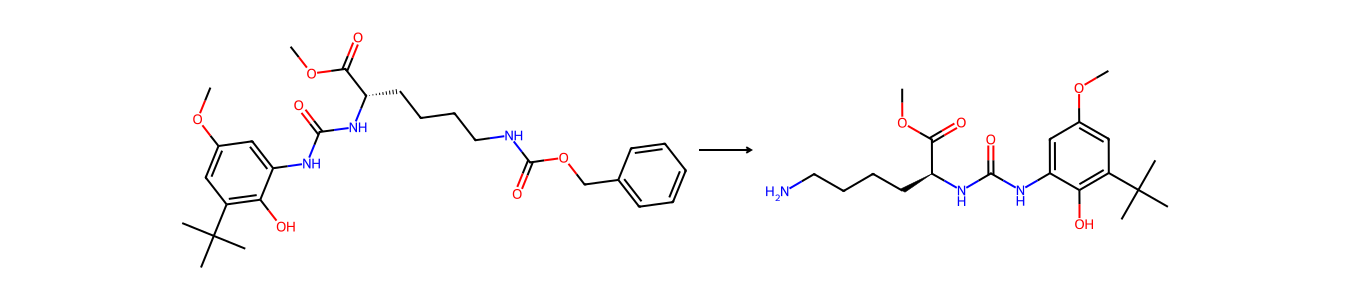

In [11]:
rsmi = (
    "COC(=O)[C@H](CCCCNC(=O)OCc1ccccc1)NC(=O)Nc1cc(OC)cc(C(C)(C)C)c1O"
    ">>"
    "COC(=O)[C@H](CCCCN)NC(=O)Nc1cc(OC)cc(C(C)(C)C)c1O"
)


print(reaction_imbalance(rsmi))
svg = visualize_reaction(
    rsmi,
    svg=True,
    highlight_changes=True,
    legend="MCS",
)

display(SVG(svg))

The missing compound has the formula **C₈H₆O₂**, which corresponds to many possible structures, making full library enumeration infeasible.  
Instead, by extracting the **maximum common subgraph** between reactants and products, the remaining unmatched portion directly reveals the **missing fragment**.


In [12]:
from synkit.IO import (
    rsmi_to_graph,
)  # to convert directly reaction smiles to reactant and product graphs
from synkit.Graph.Matcher.mcs_matcher import MCSMatcher  # fast MCS for molecular graph

r, p = rsmi_to_graph(rsmi, drop_non_aam=False, use_index_as_atom_map=False)

mcs = MCSMatcher(
    node_attrs=['element', 'charge', 'aromatic'],
    edge_attrs=['order'],
    prune_automorphisms=True,  # reduce the redundant maps
)
mcs.find_common_subgraph(r, p, mcs=True)
maps = mcs.get_mappings()
maps

[{1: 1,
  2: 2,
  3: 3,
  4: 4,
  5: 5,
  6: 6,
  7: 7,
  8: 8,
  9: 9,
  10: 10,
  11: 21,
  12: 22,
  13: 23,
  14: 24,
  15: 25,
  16: 26,
  17: 27,
  18: 28,
  19: 29,
  20: 30,
  21: 31,
  22: 32,
  23: 33,
  24: 34,
  25: 35,
  26: 36,
  27: 37}]

This mapping corresponds to a `pattern_to_host` alignment, i.e. from a
smaller molecule to a larger one.  
In this example, the mapping is from the **product** (pattern) to the
**reactant** (host).

The unmatched region in the host graph therefore identifies the
**missing subgraph**, which must be imputed to complete and rebalance
the reaction.


In [13]:
exist_indice = [value for _, value in maps[0].items()]
missing_indice = [value for value in r.nodes if value not in exist_indice]

In [14]:
import networkx as nx
from typing import Iterable


def extract_induced_subgraph(
    G: nx.Graph, nodes: Iterable[int], *, copy: bool = True
) -> nx.Graph:
    nodes = set(nodes)

    # Safety check
    missing = nodes - set(G.nodes)
    if missing:
        raise KeyError(f"Nodes not found in graph: {sorted(missing)}")

    H = G.subgraph(nodes)
    return H.copy() if copy else H

<Axes: >

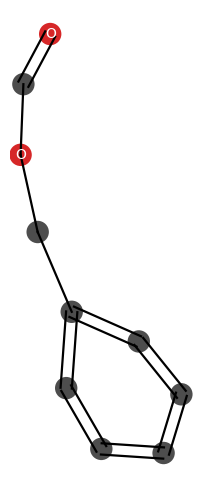

In [15]:
sub = extract_induced_subgraph(r, missing_indice)
draw_molecular_graph(sub)

**Q5 — Detect valence violations in a molecular subgraph**

Given a **molecular graph** represented as a **NetworkX graph**, detect atoms
whose **total valence violates basic chemical constraints**, using only
**local graph information** (node and edge attributes).

This exercise emphasizes a **purely graph-theoretic definition of valence**,
independent of RDKit sanitization, atom typing, or implicit chemistry rules.

---

**Step-by-step tasks**

1. **Define allowed valences**  
   Specify an extensible mapping
   $$
   \mathcal{V} : \text{Element} \;\to\; \{\text{allowed valences}\}
   $$
   for common elements (C, N, O, S, P).

2. **Compute total valence per atom**  
   For each atom $i$, compute the total valence
   $$
   v_i
   \;=\;
   h_i
   \;+\;
   \sum_{(i,j)\in E} b_{ij},
   $$
   where $h_i$ is the hydrogen count and $b_ij$ is the bond order of the
   bond between atoms $i$ and $j$.

3. **Check against valence constraints**  
   Verify whether
   $$
   v_i \in \mathcal{V}\bigl(a(i)\bigr),
   $$
   where $a(i)$ denotes the element type of atom $i$.

4. **Collect violations**  
   Record all atoms $i$ for which
   $$
   v_i \notin \mathcal{V}\bigl(a(i)\bigr).
   $$

5. **Report diagnostics**  
   For each violating atom, report:
   $$
   (\text{atom index},\; \text{element},\; v_i,\; \mathcal{V}(a(i))).
   $$

---


<details>
<summary><b>Solution:</b></summary>

```python
_ALLOWED_VALENCE = {
    "C": {4},
    "N": {3, 4},  
    "O": {2},
    "S": {2, 4, 6},
    "P": {3, 5},
}

import networkx as nx
from typing import Dict


def find_valence_violations(G: nx.Graph) -> Dict[int, Dict]:
    violations = {}

    for node, data in G.nodes(data=True):
        element = data.get("element")
        hcount = data.get("hcount", 0)

        if element not in _ALLOWED_VALENCE:
            continue  # skip unknown elements

        bond_valence = 0.0
        for nbr in G.neighbors(node):
            bond_valence += G.edges[node, nbr].get("order", 1.0)

        total_valence = hcount + bond_valence
        allowed = _ALLOWED_VALENCE[element]

        if total_valence not in allowed:
            violations[node] = {
                "element": element,
                "hcount": hcount,
                "bond_valence": bond_valence,
                "total_valence": total_valence,
                "allowed": sorted(allowed),
            }

    return violations


violations = find_valence_violations(sub)

for idx, info in violations.items():
    print(
        f"Atom {idx} ({info['element']}): "
        f"total={info['total_valence']} "
        f"(h={info['hcount']} + bonds={info['bond_valence']}), "
        f"allowed={info['allowed']}"
    )
```

</details>


Then we need to mark this atom need to be merged with some subgraphs. We introduce wildcard here

In [16]:
import networkx as nx
from typing import List


_ALLOWED_VALENCE = {
    "C": {4},
    "N": {3, 4},  # neutral amine (3), ammonium (4)
    "O": {2},
    "S": {2, 4, 6},
    "P": {3, 5},
}


def add_wildcard(
    G: nx.Graph,
    indices: List[int],
) -> nx.Graph:
    """
    Return a copy of the graph with wildcard (*) atoms added
    to balance valence for selected atoms.

    For each atom index in `indices`, compute:
        total_valence = hcount + sum(bond orders)

    If total_valence is smaller than the maximum allowed valence
    for that element, add a wildcard atom (*) connected by a bond
    whose order exactly compensates the deficit.

    Parameters
    ----------
    G : nx.Graph
        Molecular graph (original graph is NOT modified).
    indices : List[int]
        Atom indices to check and repair.

    Returns
    -------
    nx.Graph
        New graph with wildcard atoms added.
    """
    H = G.copy()

    next_idx = max(H.nodes, default=0) + 1

    for atom in indices:
        if atom not in H:
            continue

        data = H.nodes[atom]
        element = data.get("element")
        hcount = data.get("hcount", 0)

        if element not in _ALLOWED_VALENCE:
            continue

        bond_valence = sum(
            H.edges[atom, nbr].get("order", 1.0) for nbr in H.neighbors(atom)
        )

        total_valence = hcount + bond_valence
        allowed = max(_ALLOWED_VALENCE[element])

        deficit = allowed - total_valence
        if deficit <= 0:
            continue

        wc = next_idx
        next_idx += 1

        H.add_node(
            wc,
            element="*",
            aromatic=False,
            hcount=0,
            charge=0,
            wildcard=True,
        )
        H.add_edge(atom, wc, order=deficit)

    return H

In [17]:
from synkit.Graph import print_graph_attributes

wc_sub = add_wildcard(sub, indices=[11])

print_graph_attributes(wc_sub)

🔹 Nodes and their attributes:
  Node 11: {'element': 'C', 'aromatic': False, 'hcount': 0, 'charge': 0, 'neighbors': ['N', 'O', 'O'], 'atom_map': 0}
  Node 12: {'element': 'O', 'aromatic': False, 'hcount': 0, 'charge': 0, 'neighbors': ['C'], 'atom_map': 0}
  Node 13: {'element': 'O', 'aromatic': False, 'hcount': 0, 'charge': 0, 'neighbors': ['C', 'C'], 'atom_map': 0}
  Node 14: {'element': 'C', 'aromatic': False, 'hcount': 2, 'charge': 0, 'neighbors': ['C', 'O'], 'atom_map': 0}
  Node 15: {'element': 'C', 'aromatic': True, 'hcount': 0, 'charge': 0, 'neighbors': ['C', 'C', 'C'], 'atom_map': 0}
  Node 16: {'element': 'C', 'aromatic': True, 'hcount': 1, 'charge': 0, 'neighbors': ['C', 'C'], 'atom_map': 0}
  Node 17: {'element': 'C', 'aromatic': True, 'hcount': 1, 'charge': 0, 'neighbors': ['C', 'C'], 'atom_map': 0}
  Node 18: {'element': 'C', 'aromatic': True, 'hcount': 1, 'charge': 0, 'neighbors': ['C', 'C'], 'atom_map': 0}
  Node 19: {'element': 'C', 'aromatic': True, 'hcount': 1, 'charg

In [18]:
# Now we need a subgraph to merge, we try with hydroxy group
from synkit.IO import smiles_to_graph

smiles = '*[OH]'
add_sub = smiles_to_graph(smiles)
print_graph_attributes(add_sub)

🔹 Nodes and their attributes:
  Node 1: {'element': '*', 'aromatic': False, 'hcount': 0, 'charge': 0, 'neighbors': ['O'], 'atom_map': 0}
  Node 2: {'element': 'O', 'aromatic': False, 'hcount': 1, 'charge': 0, 'neighbors': ['*'], 'atom_map': 0}

🔸 Edges and their attributes:
  Edge 1-2: {'order': 1.0}


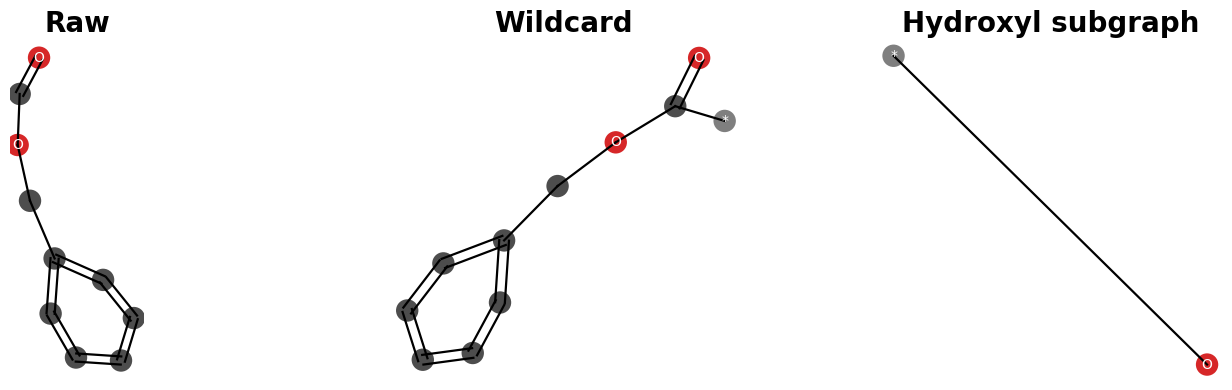

In [19]:
import matplotlib.pyplot as plt

new_sub = add_wildcard(sub, indices=[11])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
draw_molecular_graph(
    sub,
    mol=None,
    ax=axes[0],
    include_mol=False,
    highlight_nodes=None,
    highlight_edges=None,
)
axes[0].set_title("Raw", fontsize=20, weight='bold')

draw_molecular_graph(
    wc_sub,
    mol=None,
    ax=axes[1],
    include_mol=False,
    highlight_nodes=None,
    highlight_edges=None,
)
axes[1].set_title("Wildcard", fontsize=20, weight='bold')

draw_molecular_graph(
    add_sub,
    mol=None,
    ax=axes[2],
    include_mol=False,
    highlight_nodes=None,
    highlight_edges=None,
)
axes[2].set_title("Hydroxyl subgraph", fontsize=20, weight='bold')

plt.tight_layout()
plt.show()

We now merge the wildcard subgraph with the hydroxyl subgraph,
using the wildcard nodes as anchors for attachment.


In [20]:
import networkx as nx


def find_wildcards(G: nx.Graph) -> list[int]:
    """Return indices of wildcard (*) nodes."""
    return [n for n, d in G.nodes(data=True) if d.get("element") == "*"]


def _get_unique_wildcard(G: nx.Graph, label: str) -> int:
    wcs = find_wildcards(G)
    if len(wcs) != 1:
        raise ValueError(f"{label} must contain exactly one wildcard")
    return wcs[0]


def merge_graphs_on_wildcard(
    G1: nx.Graph,
    G2: nx.Graph,
    *,
    wc1: int | None = None,
    wc2: int | None = None,
) -> nx.Graph:
    """
    Merge two molecular graphs by gluing them at wildcard (*) nodes.

    The wildcard nodes are removed, and their unique neighbors are connected.
    """
    # --- identify wildcards ---
    wc1 = wc1 if wc1 is not None else _get_unique_wildcard(G1, "G1")
    wc2 = wc2 if wc2 is not None else _get_unique_wildcard(G2, "G2")

    # --- check 1–1 attachment ---
    nbrs1 = list(G1.neighbors(wc1))
    nbrs2 = list(G2.neighbors(wc2))
    if len(nbrs1) != 1 or len(nbrs2) != 1:
        raise ValueError("Only 1–1 wildcard gluing is supported")

    u1 = nbrs1[0]
    u2 = nbrs2[0]

    # --- initialize merged graph ---
    G = nx.Graph()

    # copy G1 without wildcard
    for n, d in G1.nodes(data=True):
        if n != wc1:
            G.add_node(n, **d)
    for u, v, d in G1.edges(data=True):
        if wc1 not in (u, v):
            G.add_edge(u, v, **d)

    # copy G2 without wildcard (with offset)
    offset = max(G.nodes, default=-1) + 1
    node_map = {}

    for n, d in G2.nodes(data=True):
        if n == wc2:
            continue
        node_map[n] = n + offset
        G.add_node(node_map[n], **d)

    for u, v, d in G2.edges(data=True):
        if wc2 not in (u, v):
            G.add_edge(node_map[u], node_map[v], **d)

    # --- glue the attachment points ---
    bond_order = min(
        G1.edges[wc1, u1]["order"],
        G2.edges[wc2, u2]["order"],
    )
    G.add_edge(u1, node_map[u2], order=bond_order)

    return G

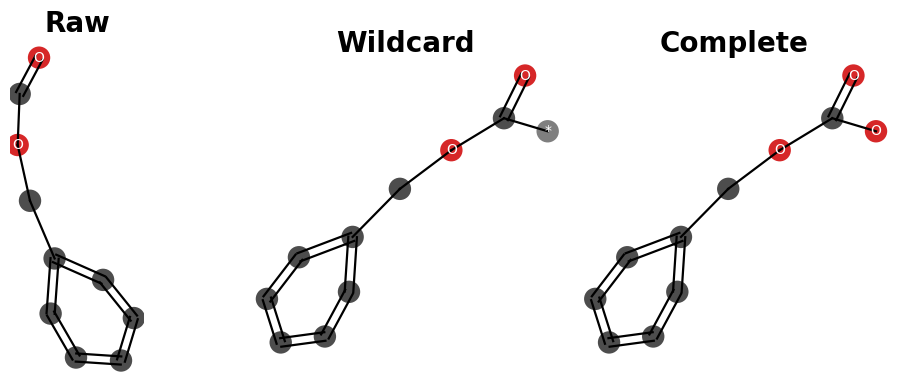

In [21]:
missing_graph = merge_graphs_on_wildcard(wc_sub, add_sub)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
draw_molecular_graph(
    sub,
    mol=None,
    ax=axes[0],
    include_mol=False,
    highlight_nodes=None,
    highlight_edges=None,
)
axes[0].set_title("Raw", fontsize=20, weight='bold')

draw_molecular_graph(
    new_sub,
    mol=None,
    ax=axes[1],
    include_mol=False,
    highlight_nodes=None,
    highlight_edges=None,
)
axes[1].set_title("Wildcard", fontsize=20, weight='bold')

draw_molecular_graph(
    missing_graph,
    mol=None,
    ax=axes[2],
    include_mol=False,
    highlight_nodes=None,
    highlight_edges=None,
)
axes[2].set_title("Complete", fontsize=20, weight='bold')

plt.tight_layout()
plt.show()

In [22]:
from synkit.IO import graph_to_smi

missing_smi = graph_to_smi(missing_graph)
print(missing_smi)

O=C(O)OCc1ccccc1


**Q6 — Reaction completion via MCS-based imputation**

You are given a reaction SMILES `rsmi` with a detected imbalance and a
missing species identified via MCS (`missing_smi`).

---

**Tasks**

1. **Impute missing structure**  
   Use `impute_smi_mcs` to add `missing_smi` to the appropriate side
   of the reaction.

2. **Re-check balance**  
   Recompute the imbalance using `reaction_imbalance`.

3. **Decide outcome**  
   - Balanced → accept reaction  
   - Unbalanced → apply further imputation


---

<details>
<summary><b>Solution:</b></summary>

```python
def impute_smi_mcs(
    rsmi: str,
    status: str,
    missing_smi: str | None = None,
) -> str | None:

    # --- trivial cases ---
    if status == "balanced" or missing_smi is None:
        return rsmi

    if status == "missing_in_both_sides":
        return None

    # --- split reaction ---
    lhs, rhs = rsmi.split(">>")

    # --- impute on the correct side ---
    if status == "missing_in_products":
        rhs = f"{rhs}.{missing_smi}" if rhs else missing_smi
    elif status == "missing_in_reactants":
        lhs = f"{lhs}.{missing_smi}" if lhs else missing_smi
    else:
        return None

    return f"{lhs}>>{rhs}"



# imput missing smiles
mcs_rsmi  = impute_smi_mcs(rsmi, status, missing_smi=missing_smi)

# re-checking
delta, status = reaction_imbalance(mcs_rsmi)
print(delta, status)

# rule-based imputation
rsmi_balanced = impute_rsmi_rule(mcs_rsmi, delta, status, library=AUX_LIBRARY)
print(rsmi_balanced)
```

Here we demonstrate the same rebalancing task using **SynRBL** [[6]](#ref-6), a dedicated
rule-based reaction rebalancer. Starting from an imbalanced reaction SMILES,
SynRBL automatically detects the missing fragment via MCS-based alignment and
completes the reaction by imputing the appropriate substructure. The output
indicates that the reaction is successfully solved, reports the applied rules,
and assigns a high confidence score, illustrating how MCS-based reasoning can
robustly recover missing species without manual intervention.


In [23]:
# pip install synrbl
from synrbl import Balancer

smiles = (
    "COC(=O)[C@H](CCCCNC(=O)OCc1ccccc1)NC(=O)Nc1cc(OC)cc(C(C)(C)C)c1O>>"
    + "COC(=O)[C@H](CCCCN)NC(=O)Nc1cc(OC)cc(C(C)(C)C)c1O"
)
synrbl = Balancer()

results = synrbl.rebalance(smiles, output_dict=True)
results

/home/lolo/miniforge3/envs/synedu/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.4.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/lolo/miniforge3/envs/synedu/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator NearestNeighbors from version 1.4.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/lolo/miniforge3/envs/synedu/lib/python3.11/pickle.py:1718: UserWarning: [16:19:41] WARNING: /workspace/src/collective/../data/../common/error_msg.h:82: If you are

[{'reaction': 'COC(=O)[C@H](CCCCNC(=O)OCc1ccccc1)NC(=O)Nc1cc(OC)cc(C(C)(C)C)c1O.O>>COC(=O)[C@H](CCCCN)NC(=O)Nc1cc(OC)cc(C(C)(C)C)c1O.O=C(O)OCc1ccccc1',
  'solved': True,
  'input_reaction': 'COC(=O)[C@H](CCCCNC(=O)OCc1ccccc1)NC(=O)Nc1cc(OC)cc(C(C)(C)C)c1O>>COC(=O)[C@H](CCCCN)NC(=O)Nc1cc(OC)cc(C(C)(C)C)c1O',
  'issue': '',
  'rules': ['append O when next to O or N', 'default single bond'],
  'solved_by': 'mcs-based',
  'confidence': 0.9990000128746033}]

## 4. Discussion

- **MCS** is a useful alignment primitive but is heuristic and may yield
  non-unique solutions.
- Many reactions in databases are **incomplete**, most often missing water
  or other small molecules.
- Library-based imputation is feasible for **non-carbon species** but becomes
  intractable for carbon-containing compounds.
- **MCS-based methods** help localize missing carbon fragments but still require
  chemical rules and domain knowledge for valid completion.
- **SynRBL** combines MCS alignment with rule-based reasoning to perform
  practical reaction rebalancing.


## 5. Quiz

- Why is MCS considered a heuristic rather than an exact method for
reaction alignment?

-  Which types of missing species are most commonly found in incomplete
reaction databases, and why are they easier to impute?

- Why does library-based imputation scale poorly for carbon-containing
compounds?

- What information can MCS provide when rebalancing reactions involving
missing carbon fragments?


## 6. References

1. <a id="ref-1"></a> RDKit documentation: https://www.rdkit.org/docs/  
2. <a id="ref-2"></a> NetworkX documentation: https://networkx.org/documentation/stable/
3. <a id="ref-3"></a> Bonchev, D., & Rouvray, D. H. (eds.).  
   *Chemical Graph Theory: Introduction and Fundamentals*.  
   Abacus Press, 1991.  
   ISBN: 978-0856267588  
   — Classic reference linking molecular graphs, symmetry, and
   **automorphism groups** to chemical interpretation.

4. <a id="ref-4"></a> Diestel, R.  
   *Graph Theory* (5th ed.).  
   Springer, 2017.  
   DOI: 10.1007/978-3-662-53622-3  
   — Authoritative mathematical treatment of **graph morphisms**,
   **isomorphisms**, **automorphisms**, and group actions on graphs.

5. <a id="ref-5"></a> RDKit MCS (rdFMCS): https://www.rdkit.org/docs/source/rdkit.Chem.rdFMCS.html

6. <a id="ref-6"></a> **Reaction rebalancing**: a novel approach to curating reaction databases   
   Phan, T.-L. *et al.* *Journal of Cheminformatics* **16**, 82 (2024).  
   https://doi.org/10.1186/s13321-024-00875-4

7. <a id="ref-7"></a> **SynKit**: A graph-based framework for rule-based reaction modeling  
   Phan, T.-L. *et al.* *Journal of Chemical Information and Modeling* (2025).  
   https://doi.org/10.1021/acs.jcim.5c02123


